# Calcium soma review notebook

This notebook is set up for **fast browsing of somatic Ca$^{2+}$ responses across sessions** using:

- `calcium_mean_dff.npz`
- `calcium_single_trial_dff.npz`
- `calcium_sequence_dff.npz`
- the soma QC/metadata table in `slap2_cell_table.pkl`

It is organized to help answer questions like:

- Which somata look strongly image responsive?
- Do the same cells respond to **Change** and **Omission** events?
- Do sequence responses show **adaptation/facilitation motifs** similar to the synaptic data?
- How do these effects vary with depth, session type, and QC?


In [1]:
from pathlib import Path
from functools import lru_cache
import math
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, HTML
from vip_slap2_analysis.io.session_registry import VIPSessionRegistry

display(HTML("<style>.container { width:100% !important; }</style>"))

%load_ext autoreload
%autoreload 2

plt.rcParams["figure.dpi"] = 120
sns.set_context("talk", font_scale=0.8)
sns.set_style("white")


In [19]:
%matplotlib notebook

In [3]:
# --- user config ---

BASEPATH = r'\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics'

target_mice = [
#     803496,
#     804730, 804733, 810196,
#     809047, 803121,
    826033, 838410, 834788,
]

USE_VALID_ROIS_ONLY = True
MIN_ROBUST_SNR = None     # e.g. 1.25
REQUIRE_ALL_NPZ = False   # if True, keep only rows with mean + single_trial + sequence

IMAGE_PRE_WINDOW = (-0.25, 0.00)
IMAGE_POST_WINDOW = (0.00, 0.25)

CHANGE_PRE_WINDOW = (-0.25, 0.00)
CHANGE_POST_WINDOW = (0.00, 0.25)

OMISSION_PRE_WINDOW = (-0.25, 0.00)
OMISSION_POST_WINDOW = (0.00, 0.75)

# local / uploaded pickle fallbacks
CELL_TABLE_CANDIDATES = [
    Path("slap2_cell_table.pkl"),
    Path(r"C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Data_Club\April2026\data\slap2_cell_table.pkl"),
]

CELL_TABLE_PATH = next((p for p in CELL_TABLE_CANDIDATES if p.exists()), CELL_TABLE_CANDIDATES[0])
print("Using cell table:", CELL_TABLE_PATH)


Using cell table: C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Data_Club\April2026\data\slap2_cell_table.pkl


In [4]:
registry = VIPSessionRegistry.from_basepath(BASEPATH)

process_df = registry.sessions(
    subject_ids=target_mice,
    exclude_session_types=["expression_check", "volume_imaging"],
    paradigms=["change_detection_passive"],
).copy()

assets = [registry.resolve_assets(row) for _, row in process_df.iterrows()]

print(f"{len(process_df)} sessions in process_df")
display(process_df.head())


20 sessions in process_df


,session_id,subject_id,session_#,session_date,indicator1,indicator2,dmd1_depth,dmd2_depth,paradigm,session_type,...,instrument_id,camera_type,has raster ROI?,has integration roi?,behavior_rig,quality,flags,session_dir,purpose,notes
0,826033_2026-02-21_09-23-34,826033,2,2026-02-21,iGluSnFR4,RCaMP3,25,200,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,no,VCO.1,good,MoCo failed in last 3min of experiment,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
1,826033_2026-02-23_10-45-21,826033,3,2026-02-23,iGluSnFR4,RCaMP3,25,200,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,no,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
2,826033_2026-02-24_14-14-45,826033,4,2026-02-24,iGluSnFR4,RCaMP3,25,200,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,no,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,Some photodamage to a small segment of a large...
3,826033_2026-02-25_08-49-29,826033,5,2026-02-25,iGluSnFR4,RCaMP3,25,200,change_detection_passive,novel,...,SLAP2_1,spinnaker,yes,no,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
4,826033_2026-02-26_12-40-54,826033,6,2026-02-26,iGluSnFR4,RCaMP3,25,200,change_detection_passive,novel+,...,SLAP2_1,spinnaker,yes,no,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN


In [5]:
def _asset_get(asset, name, default=None):
    if isinstance(asset, dict):
        return asset.get(name, default)
    return getattr(asset, name, default)

def _find_first(root, pattern):
    if root is None:
        return None
    root = Path(root)
    if not root.exists():
        return None
    matches = sorted(root.rglob(pattern))
    return matches[0] if matches else None

def find_calcium_artifacts(asset):
    derived_dir = _asset_get(asset, "derived_dir", None)
    derived_dir = Path(derived_dir) if derived_dir is not None else None

    if derived_dir is None:
        return {"derived_dir": None, "mean_path": None, "single_trial_path": None, "sequence_path": None}

    search_root = derived_dir / "calcium" if (derived_dir / "calcium").exists() else derived_dir

    return {
        "derived_dir": str(derived_dir),
        "mean_path": _find_first(search_root, "calcium_mean_dff.npz"),
        "single_trial_path": _find_first(search_root, "calcium_single_trial_dff.npz"),
        "sequence_path": _find_first(search_root, "calcium_sequence_dff.npz"),
    }

artifact_records = []
for (_, row), asset in zip(process_df.iterrows(), assets):
    rec = {
        "subject_id": row.get("subject_id", np.nan),
        "session_id": row.get("session_id", None),
        "session_type": row.get("session_type", None),
        "date": row.get("date", None),
    }
    rec.update(find_calcium_artifacts(asset))
    artifact_records.append(rec)

artifact_df = pd.DataFrame(artifact_records)
for col in ["mean_path", "single_trial_path", "sequence_path"]:
    artifact_df[col] = artifact_df[col].astype("object")

display(artifact_df.head())
display(
    artifact_df.assign(
        has_mean=artifact_df["mean_path"].notna(),
        has_single_trial=artifact_df["single_trial_path"].notna(),
        has_sequence=artifact_df["sequence_path"].notna(),
    )[["session_id", "session_type", "has_mean", "has_single_trial", "has_sequence"]]
)


,subject_id,session_id,session_type,date,derived_dir,mean_path,single_trial_path,sequence_path
0,826033,826033_2026-02-21_09-23-34,familiar,None,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
1,826033,826033_2026-02-23_10-45-21,familiar,None,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
2,826033,826033_2026-02-24_14-14-45,familiar,None,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
3,826033,826033_2026-02-25_08-49-29,novel,None,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
4,826033,826033_2026-02-26_12-40-54,novel+,None,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...


,session_id,session_type,has_mean,has_single_trial,has_sequence
0,826033_2026-02-21_09-23-34,familiar,True,True,True
1,826033_2026-02-23_10-45-21,familiar,True,True,True
2,826033_2026-02-24_14-14-45,familiar,True,True,True
3,826033_2026-02-25_08-49-29,novel,True,True,True
4,826033_2026-02-26_12-40-54,novel+,True,True,True
5,826033_2026-02-27_13-53-35,novel+,True,True,True
6,834788_2026-03-02_10-18-42,familiar,True,True,True
7,834788_2026-03-03_09-22-19,familiar,True,True,True
8,834788_2026-03-04_08-43-07,familiar,True,True,True
9,834788_2026-03-05_08-11-16,familiar,True,True,True


In [6]:
cell_table = pd.read_pickle(CELL_TABLE_PATH).copy()

cell_table["session_id"] = cell_table["session_id"].astype(str)
cell_table["fov_id"] = cell_table["fov_id"].astype(str).str.upper()
cell_table["roi_id"] = cell_table["roi_id"].astype(int)

if USE_VALID_ROIS_ONLY and "valid_roi" in cell_table.columns:
    cell_table = cell_table[cell_table["valid_roi"].fillna(False)].copy()

if MIN_ROBUST_SNR is not None and "robust_snr" in cell_table.columns:
    cell_table = cell_table[cell_table["robust_snr"] >= MIN_ROBUST_SNR].copy()

review_df = cell_table.merge(
    artifact_df,
    on=["subject_id", "session_id", "session_type"],
    how="left",
)

review_df["has_mean"] = review_df["mean_path"].notna()
review_df["has_single_trial"] = review_df["single_trial_path"].notna()
review_df["has_sequence"] = review_df["sequence_path"].notna()

if REQUIRE_ALL_NPZ:
    review_df = review_df[
        review_df["has_mean"] &
        review_df["has_single_trial"] &
        review_df["has_sequence"]
    ].copy()
else:
    review_df = review_df[review_df["has_mean"]].copy()

print(f"{len(review_df)} soma rows after filters")
display(review_df.head())

session_overview = (
    review_df.groupby(["session_id", "session_type", "fov_id", "z"], dropna=False)
    .agg(
        n_rois=("roi_id", "nunique"),
        median_snr=("robust_snr", "median"),
        mean_snr=("robust_snr", "mean"),
        has_mean=("has_mean", "max"),
        has_single_trial=("has_single_trial", "max"),
        has_sequence=("has_sequence", "max"),
    )
    .reset_index()
    .sort_values(["session_type", "session_id", "fov_id"])
)

display(session_overview)


85 soma rows after filters


,subject_id,session_id,session_date,session_type,stimulus_block,z,roi_id,fov_id,dff,valid_roi,...,robust_signal,robust_snr,date,derived_dir,mean_path,single_trial_path,sequence_path,has_mean,has_single_trial,has_sequence
0,838410,838410_2026-03-20_10-00-59,2026-03-20T00:00:00,novel+,change_detection_passive,25.0,0,DMD2,"[-0.03479761510003118, -0.025666933892175642, ...",True,...,0.046157,1.472481,None,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,True,True,True
1,838410,838410_2026-03-20_10-00-59,2026-03-20T00:00:00,novel+,change_detection_passive,25.0,1,DMD2,"[0.05614713662335182, 0.0737129624837686, -0.0...",True,...,0.058512,1.623428,None,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,True,True,True
2,838410,838410_2026-03-20_10-00-59,2026-03-20T00:00:00,novel+,change_detection_passive,25.0,3,DMD2,"[0.06617241502830179, 0.1456603170533158, 0.12...",True,...,0.077168,1.468941,None,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,True,True,True
3,834788,834788_2026-03-19_09-05-56,2026-03-19T00:00:00,novel+,change_detection_passive,200.0,1,DMD1,"[0.015621435112213406, 0.008803731708923223, 0...",True,...,0.073473,1.491969,None,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,True,True,True
4,834788,834788_2026-03-19_09-05-56,2026-03-19T00:00:00,novel+,change_detection_passive,200.0,2,DMD1,"[-0.03308366679644715, -0.03621395234026183, -...",True,...,0.034796,1.533814,None,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,True,True,True


,session_id,session_type,fov_id,z,n_rois,median_snr,mean_snr,has_mean,has_single_trial,has_sequence
0,826033_2026-02-21_09-23-34,familiar,DMD1,25.0,3,1.479284,1.478110,True,True,True
1,826033_2026-02-21_09-23-34,familiar,DMD2,200.0,4,1.446197,1.444382,True,True,True
2,826033_2026-02-23_10-45-21,familiar,DMD1,25.0,1,1.451754,1.451754,True,True,True
3,826033_2026-02-23_10-45-21,familiar,DMD2,200.0,4,1.455825,1.452450,True,True,True
4,826033_2026-02-24_14-14-45,familiar,DMD1,25.0,1,1.471734,1.471734,True,True,True
5,826033_2026-02-24_14-14-45,familiar,DMD2,200.0,3,1.465637,1.457421,True,True,True
9,834788_2026-03-02_10-18-42,familiar,DMD1,25.0,1,1.541386,1.541386,True,True,True
10,834788_2026-03-02_10-18-42,familiar,DMD2,200.0,4,1.464241,1.471958,True,True,True
11,834788_2026-03-03_09-22-19,familiar,DMD1,25.0,1,1.568227,1.568227,True,True,True
12,834788_2026-03-03_09-22-19,familiar,DMD2,200.0,4,1.489119,1.488600,True,True,True


In [7]:
def roi_num_from_any(x):
    if isinstance(x, (int, np.integer)):
        return int(x)
    s = str(x)
    m = re.search(r"roi0*(\d+)$", s)
    if m:
        return int(m.group(1))
    return int(float(s))

def dmd_key(dmd):
    if isinstance(dmd, str) and dmd.upper().startswith("DMD"):
        return dmd.upper()
    return f"DMD{int(dmd)}"

@lru_cache(maxsize=None)
def load_npz_data(path_like):
    path_like = str(path_like)
    return np.load(path_like, allow_pickle=True)["data"][0]

def get_dmd_payload(data, dmd):
    return data[dmd_key(dmd)]

def _infer_n_rois_from_payload(payload):
    if "image_identity" in payload and len(payload["image_identity"]) > 0:
        first = next(iter(payload["image_identity"].values()))
        if isinstance(first, dict) and "mean" in first:
            arr = np.asarray(first["mean"])
            return arr.shape[0] if arr.ndim == 2 else arr.shape[1]
        arr = np.asarray(first)
        if arr.ndim == 3:
            return arr.shape[1]
    if "change" in payload:
        ch = payload["change"]
        if isinstance(ch, dict) and "mean" in ch:
            return np.asarray(ch["mean"]).shape[0]
        return np.asarray(ch).shape[1]
    return None

def get_roi_index(data, dmd, roi_id):
    payload = get_dmd_payload(data, dmd)
    roi_id = int(roi_id)

    roi_ids = np.asarray(payload.get("roi_ids", []))
    if roi_ids.size > 0:
        lookup = {}
        for i, rid in enumerate(roi_ids):
            try:
                lookup[roi_num_from_any(rid)] = i
            except Exception:
                pass
        if roi_id in lookup:
            return lookup[roi_id]

    n_rois = _infer_n_rois_from_payload(payload)
    if n_rois is not None and 0 <= roi_id < n_rois:
        return roi_id

    return None

def event_metrics(trace, timebase, pre_window, post_window):
    trace = np.asarray(trace, dtype=float)
    timebase = np.asarray(timebase, dtype=float)

    pre_mask = (timebase >= pre_window[0]) & (timebase < pre_window[1])
    post_mask = (timebase >= post_window[0]) & (timebase < post_window[1])

    baseline = np.nanmean(trace[pre_mask]) if np.any(pre_mask) else 0.0
    delta = trace - baseline
    post = delta[post_mask]
    post_t = timebase[post_mask]

    if post.size == 0 or np.all(np.isnan(post)):
        return {
            "baseline": baseline,
            "post_mean": np.nan,
            "post_peak": np.nan,
            "post_auc": np.nan,
        }

    return {
        "baseline": baseline,
        "post_mean": np.nanmean(post),
        "post_peak": np.nanmax(post),
        "post_auc": np.trapz(np.nan_to_num(post, nan=0.0), post_t),
    }

def short_image_name(image_id):
    return Path(str(image_id)).stem

def compute_image_response_df(mean_data, dmd, roi_id):
    payload = get_dmd_payload(mean_data, dmd)
    roi_idx = get_roi_index(mean_data, dmd, roi_id)
    if roi_idx is None:
        return pd.DataFrame()

    timebase = np.asarray(mean_data["timebase_sec"]["image"])
    rows = []

    for image_id, item in payload["image_identity"].items():
        trace = np.asarray(item["mean"])[roi_idx]
        mets = event_metrics(trace, timebase, IMAGE_PRE_WINDOW, IMAGE_POST_WINDOW)
        rows.append({
            "image_id": image_id,
            "image_name": short_image_name(image_id),
            **mets,
        })

    return pd.DataFrame(rows).sort_values("post_mean", ascending=False)

def compute_sequence_matrix(seq_data, dmd, roi_id):
    payload = get_dmd_payload(seq_data, dmd)
    roi_idx = get_roi_index(seq_data, dmd, roi_id)
    if roi_idx is None:
        return None, None, None

    timebase = np.asarray(seq_data["timebase_sec"]["image"])
    rows = []
    row_labels = []
    col_labels = None

    for image_id, item in payload["image_identity"].items():
        vals = []
        labels = []

        pre = item["prechange"]
        if isinstance(pre, dict) and "mean" in pre:
            for pos, tr in zip(np.asarray(pre["positions"]), np.asarray(pre["mean"])[:, roi_idx, :]):
                vals.append(event_metrics(tr, timebase, IMAGE_PRE_WINDOW, IMAGE_POST_WINDOW)["post_mean"])
                labels.append(f"pre{int(pos)}")

        rep = item["repeated"]
        if isinstance(rep, dict) and "mean" in rep:
            for pos, tr in zip(np.asarray(rep["positions"]), np.asarray(rep["mean"])[:, roi_idx, :]):
                vals.append(event_metrics(tr, timebase, IMAGE_PRE_WINDOW, IMAGE_POST_WINDOW)["post_mean"])
                labels.append(f"r{int(pos)}")

        term = item["terminal"]
        if isinstance(term, dict) and "mean" in term:
            tr = np.asarray(term["mean"])[roi_idx]
            vals.append(event_metrics(tr, timebase, IMAGE_PRE_WINDOW, IMAGE_POST_WINDOW)["post_mean"])
            term_pos = np.asarray(term.get("position", ["T"])).ravel()
            labels.append(f"term{term_pos[0]}")

        if col_labels is None or len(labels) > len(col_labels):
            col_labels = labels

        rows.append(vals)
        row_labels.append(short_image_name(image_id))

    if len(rows) == 0:
        return None, None, None

    max_len = max(len(r) for r in rows)
    mat = np.full((len(rows), max_len), np.nan, dtype=float)
    for i, r in enumerate(rows):
        mat[i, :len(r)] = r

    if col_labels is None:
        col_labels = [str(i) for i in range(max_len)]
    elif len(col_labels) < max_len:
        col_labels = list(col_labels) + [f"p{i}" for i in range(len(col_labels), max_len)]

    return mat, row_labels, col_labels


In [8]:
summary_records = []

for row in review_df.itertuples(index=False):
    if pd.isna(row.mean_path):
        continue

    mean_data = load_npz_data(row.mean_path)
    roi_idx = get_roi_index(mean_data, row.fov_id, row.roi_id)
    if roi_idx is None:
        continue

    img_df = compute_image_response_df(mean_data, row.fov_id, row.roi_id)
    if len(img_df) == 0:
        continue

    best_image = img_df.iloc[0]

    change_metrics = {"post_mean": np.nan, "post_peak": np.nan, "post_auc": np.nan}
    omission_metrics = {"post_mean": np.nan, "post_peak": np.nan, "post_auc": np.nan}

    payload = get_dmd_payload(mean_data, row.fov_id)

    if "change" in payload and isinstance(payload["change"], dict):
        trace = np.asarray(payload["change"]["mean"])[roi_idx]
        change_metrics = event_metrics(
            trace,
            np.asarray(mean_data["timebase_sec"]["change"]),
            CHANGE_PRE_WINDOW,
            CHANGE_POST_WINDOW,
        )

    if "omission" in payload and isinstance(payload["omission"], dict):
        trace = np.asarray(payload["omission"]["mean"])[roi_idx]
        omission_metrics = event_metrics(
            trace,
            np.asarray(mean_data["timebase_sec"]["omission"]),
            OMISSION_PRE_WINDOW,
            OMISSION_POST_WINDOW,
        )

    seq_peak = np.nan
    if pd.notna(row.sequence_path):
        seq_data = load_npz_data(row.sequence_path)
        seq_mat, _, _ = compute_sequence_matrix(seq_data, row.fov_id, row.roi_id)
        if seq_mat is not None:
            seq_peak = np.nanmax(seq_mat)

    summary_records.append({
        "subject_id": row.subject_id,
        "session_id": row.session_id,
        "session_type": row.session_type,
        "fov_id": row.fov_id,
        "z": row.z,
        "roi_id": row.roi_id,
        "valid_roi": row.valid_roi if "valid_roi" in review_df.columns else True,
        "robust_snr": row.robust_snr if "robust_snr" in review_df.columns else np.nan,
        "mean_path": row.mean_path,
        "single_trial_path": row.single_trial_path,
        "sequence_path": row.sequence_path,
        "best_image_id": best_image["image_id"],
        "best_image_name": best_image["image_name"],
        "best_image_post_mean": best_image["post_mean"],
        "best_image_post_peak": best_image["post_peak"],
        "best_image_post_auc": best_image["post_auc"],
        "mean_image_post_mean": img_df["post_mean"].mean(),
        "image_response_range": img_df["post_mean"].max() - img_df["post_mean"].min(),
        "image_response_std": img_df["post_mean"].std(ddof=0),
        "n_images": len(img_df),
        "change_post_mean": change_metrics["post_mean"],
        "change_post_peak": change_metrics["post_peak"],
        "change_post_auc": change_metrics["post_auc"],
        "omission_post_mean": omission_metrics["post_mean"],
        "omission_post_peak": omission_metrics["post_peak"],
        "omission_post_auc": omission_metrics["post_auc"],
        "sequence_peak_post_mean": seq_peak,
    })

response_summary_df = pd.DataFrame(summary_records)

display(response_summary_df.sort_values(
    ["best_image_post_mean", "change_post_mean", "omission_post_mean"],
    ascending=False
).head(20))

session_browser_df = (
    response_summary_df.groupby(["session_id", "session_type", "fov_id", "z"], dropna=False)
    .agg(
        n_rois=("roi_id", "nunique"),
        median_snr=("robust_snr", "median"),
        mean_best_image=("best_image_post_mean", "mean"),
        max_best_image=("best_image_post_mean", "max"),
        mean_change=("change_post_mean", "mean"),
        max_change=("change_post_mean", "max"),
        mean_omission=("omission_post_mean", "mean"),
        max_omission=("omission_post_mean", "max"),
        max_sequence_peak=("sequence_peak_post_mean", "max"),
    )
    .reset_index()
    .sort_values(["max_best_image", "max_change", "max_omission"], ascending=False)
)

display(session_browser_df.head(30))


C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_39424\3469312672.py:67: RuntimeWarning: Mean of empty slice
  baseline = np.nanmean(trace[pre_mask]) if np.any(pre_mask) else 0.0


,subject_id,session_id,session_type,fov_id,z,roi_id,valid_roi,robust_snr,mean_path,single_trial_path,...,image_response_range,image_response_std,n_images,change_post_mean,change_post_peak,change_post_auc,omission_post_mean,omission_post_peak,omission_post_auc,sequence_peak_post_mean
36,834788,834788_2026-03-20_12-44-00,novel+,DMD2,25.0,3,True,2.785081,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,...,7.055460e+07,2.526791e+07,7,6.696368e+06,9.122363e+07,1.712256e+06,3.445344e+07,3.008130e+08,2.576961e+07,5.416913e+08
69,834788,834788_2026-03-03_09-22-19,familiar,DMD2,200.0,1,True,1.495930,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,...,3.103396e-02,1.121226e-02,7,2.600616e-02,4.425533e-02,6.395737e-03,-4.500542e-03,6.006459e-02,-3.319882e-03,2.758396e-01
72,834788,834788_2026-03-04_08-43-07,familiar,DMD1,25.0,0,True,1.505458,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,...,1.449075e-02,4.898766e-03,7,7.805210e-03,2.644909e-02,1.882387e-03,-1.367292e-02,3.033552e-02,-1.024210e-02,1.191653e-01
29,838410,838410_2026-03-04_12-54-47,familiar,DMD2,200.0,2,True,1.476601,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,...,1.299793e-02,4.389800e-03,7,7.037836e-03,2.025157e-02,1.767948e-03,2.628189e-02,9.838613e-02,1.955681e-02,9.383764e-02
64,834788,834788_2026-03-02_10-18-42,familiar,DMD2,200.0,1,True,1.461901,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,...,2.509065e-02,7.766200e-03,7,-7.105823e-03,8.209543e-03,-1.773428e-03,-1.646759e-02,1.703653e-02,-1.238577e-02,8.447075e-02
58,834788,834788_2026-03-05_08-11-16,familiar,DMD2,200.0,2,True,1.446488,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,...,1.593008e-02,5.745842e-03,7,7.947879e-03,1.691983e-02,1.938300e-03,-3.397829e-02,2.792101e-03,-2.530861e-02,1.335735e-01
75,834788,834788_2026-03-04_08-43-07,familiar,DMD2,200.0,2,True,1.565716,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,...,2.282995e-02,7.821534e-03,7,3.133170e-03,2.215783e-02,7.603399e-04,-6.335947e-03,9.579019e-02,-4.822042e-03,4.624116e-01
39,838410,838410_2026-03-02_12-40-55,familiar,DMD1,25.0,2,True,1.431940,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,...,8.602482e-03,2.785894e-03,7,1.054241e-03,1.013991e-02,2.517937e-04,1.227112e-02,4.078059e-02,9.152465e-03,5.623523e-02
50,826033,826033_2026-02-23_10-45-21,familiar,DMD2,200.0,3,True,1.434436,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,...,5.619106e-03,1.643296e-03,7,2.745946e-03,8.072876e-03,6.752033e-04,-3.791163e-03,1.961870e-02,-2.840226e-03,3.605778e-02
27,838410,838410_2026-03-04_12-54-47,familiar,DMD2,200.0,0,True,1.442279,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,...,9.651104e-03,3.540716e-03,7,-5.078160e-04,5.852512e-03,-1.088523e-04,2.231742e-03,4.098483e-02,1.659737e-03,7.651030e-02


,session_id,session_type,fov_id,z,n_rois,median_snr,mean_best_image,max_best_image,mean_change,max_change,mean_omission,max_omission,max_sequence_peak
20,834788_2026-03-20_12-44-00,novel+,DMD2,25.0,3,1.528882,1.071757e+07,3.215272e+07,2.232123e+06,6.696368e+06,1.148448e+07,3.445344e+07,5.416913e+08
12,834788_2026-03-03_09-22-19,familiar,DMD2,200.0,4,1.489119,1.094332e-02,3.896153e-02,6.087073e-03,2.600616e-02,-3.955142e-03,-7.643861e-04,2.758396e-01
13,834788_2026-03-04_08-43-07,familiar,DMD1,25.0,1,1.505458,1.329429e-02,1.329429e-02,7.805210e-03,7.805210e-03,-1.367292e-02,-1.367292e-02,1.191653e-01
25,838410_2026-03-04_12-54-47,familiar,DMD2,200.0,4,1.487096,5.059578e-03,1.275916e-02,6.754050e-04,7.037836e-03,6.789822e-03,2.628189e-02,9.820024e-02
10,834788_2026-03-02_10-18-42,familiar,DMD2,200.0,4,1.464241,2.709542e-03,1.021307e-02,-2.188833e-03,6.040221e-04,-6.047923e-03,-1.156252e-03,8.447075e-02
15,834788_2026-03-05_08-11-16,familiar,DMD2,200.0,2,1.440928,5.161707e-03,9.585426e-03,3.634065e-03,7.947879e-03,-1.521757e-02,3.543148e-03,1.335735e-01
14,834788_2026-03-04_08-43-07,familiar,DMD2,200.0,3,1.565716,1.181482e-03,7.668679e-03,-1.004305e-03,3.133170e-03,-6.924290e-03,-1.889341e-03,4.624116e-01
21,838410_2026-03-02_12-40-55,familiar,DMD1,25.0,4,1.438419,2.789225e-03,4.900158e-03,2.376003e-04,2.848317e-03,4.509377e-03,1.227112e-02,7.281758e-02
3,826033_2026-02-23_10-45-21,familiar,DMD2,200.0,4,1.455825,2.646017e-03,4.771240e-03,1.982794e-03,3.145805e-03,4.800014e-04,7.445852e-03,4.586511e-02
0,826033_2026-02-21_09-23-34,familiar,DMD1,25.0,3,1.479284,2.891504e-03,3.959123e-03,6.308869e-04,2.089997e-03,-1.019870e-03,9.744212e-04,5.428851e-02


In [9]:
def get_summary_row(session_id, fov_id, roi_id):
    fov_id = dmd_key(fov_id)
    sub = response_summary_df[
        (response_summary_df["session_id"] == session_id) &
        (response_summary_df["fov_id"] == fov_id) &
        (response_summary_df["roi_id"] == int(roi_id))
    ]
    if len(sub) == 0:
        raise ValueError(f"No row found for {session_id}, {fov_id}, roi {roi_id}")
    return sub.iloc[0]

def plot_mean_image_responses(row, ax=None, legend=False):
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 3))

    mean_data = load_npz_data(row["mean_path"])
    img_df = compute_image_response_df(mean_data, row["fov_id"], row["roi_id"])
    timebase = np.asarray(mean_data["timebase_sec"]["image"])
    payload = get_dmd_payload(mean_data, row["fov_id"])
    roi_idx = get_roi_index(mean_data, row["fov_id"], row["roi_id"])

    colors = plt.cm.tab10(np.linspace(0, 1, max(len(img_df), 3)))
    for color, rec in zip(colors, img_df.itertuples(index=False)):
        trace = np.asarray(payload["image_identity"][rec.image_id]["mean"])[roi_idx]
        ax.plot(timebase, trace, lw=1.6, color=color, alpha=0.95, label=f"{rec.image_name} ({rec.post_mean:.3f})")

    ax.axvspan(0, 0.25, color="0.9", alpha=0.5, zorder=-10)
    ax.axvline(0, color="0.3", lw=0.8)
    ax.set_title(f"Image means | best={row['best_image_name']}")
    ax.set_xlabel("Time from image onset (s)")
    ax.set_ylabel("dF/F")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if legend:
        ax.legend(frameon=False, fontsize=8, ncol=2)

def plot_change_response(row, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 3))

    mean_data = load_npz_data(row["mean_path"])
    payload = get_dmd_payload(mean_data, row["fov_id"])
    if "change" not in payload or not isinstance(payload["change"], dict):
        ax.set_axis_off()
        ax.set_title("No change data")
        return

    roi_idx = get_roi_index(mean_data, row["fov_id"], row["roi_id"])
    timebase = np.asarray(mean_data["timebase_sec"]["change"])
    trace = np.asarray(payload["change"]["mean"])[roi_idx]

    ax.plot(timebase, trace, color="#3b82f6", lw=1.8)
    ax.axvspan(0, 0.25, color="0.9", alpha=0.5, zorder=-10)
    ax.axvline(0, color="0.3", lw=0.8)
    ax.set_title(f"Change | mean={row['change_post_mean']:.3f}")
    ax.set_xlabel("Time from change (s)")
    ax.set_ylabel("dF/F")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

def plot_omission_response(row, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 3))

    mean_data = load_npz_data(row["mean_path"])
    payload = get_dmd_payload(mean_data, row["fov_id"])
    if "omission" not in payload or not isinstance(payload["omission"], dict):
        ax.set_axis_off()
        ax.set_title("No omission data")
        return

    roi_idx = get_roi_index(mean_data, row["fov_id"], row["roi_id"])
    timebase = np.asarray(mean_data["timebase_sec"]["omission"])
    trace = np.asarray(payload["omission"]["mean"])[roi_idx]

    ax.plot(timebase, trace, color="#ef4444", lw=1.8)
    ax.axvline(0, color="0.3", lw=0.8)
    ax.set_title(f"Omission | mean={row['omission_post_mean']:.3f}")
    ax.set_xlabel("Time from omission (s)")
    ax.set_ylabel("dF/F")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

def plot_sequence_heatmap(row, ax=None, cmap="coolwarm"):
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 3))

    if pd.isna(row["sequence_path"]):
        ax.set_axis_off()
        ax.set_title("No sequence data")
        return

    seq_data = load_npz_data(row["sequence_path"])
    mat, row_labels, col_labels = compute_sequence_matrix(seq_data, row["fov_id"], row["roi_id"])

    if mat is None:
        ax.set_axis_off()
        ax.set_title("No sequence data")
        return

    order = np.argsort(np.nanmax(mat, axis=1))[::-1]
    mat = mat[order]
    row_labels = [row_labels[i] for i in order]

    vmax = np.nanpercentile(np.abs(mat), 98) if np.isfinite(mat).any() else 1.0
    vmax = max(vmax, 1e-6)

    im = ax.imshow(mat, aspect="auto", cmap=cmap, vmin=-vmax, vmax=vmax)
    ax.set_title("Sequence response heatmap")
    ax.set_xlabel("Sequence position")
    ax.set_ylabel("Image")
    ax.set_xticks(np.arange(len(col_labels)))
    ax.set_xticklabels(col_labels, rotation=90, fontsize=8)
    ax.set_yticks(np.arange(len(row_labels)))
    ax.set_yticklabels(row_labels, fontsize=8)
    plt.colorbar(im, ax=ax, shrink=0.7, pad=0.02, label="post-stim dF/F")

def plot_best_image_single_trials(row, ax=None, center_each_trial=True):
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 3))

    if pd.isna(row["single_trial_path"]):
        ax.set_axis_off()
        ax.set_title("No single-trial data")
        return

    st_data = load_npz_data(row["single_trial_path"])
    payload = get_dmd_payload(st_data, row["fov_id"])
    roi_idx = get_roi_index(st_data, row["fov_id"], row["roi_id"])
    if roi_idx is None:
        ax.set_axis_off()
        ax.set_title("ROI not found")
        return

    if row["best_image_id"] not in payload["image_identity"]:
        ax.set_axis_off()
        ax.set_title("Best image missing")
        return

    timebase = np.asarray(st_data["timebase_sec"]["image"])
    arr = np.asarray(payload["image_identity"][row["best_image_id"]])[:, roi_idx, :]

    if center_each_trial:
        pre_mask = (timebase >= IMAGE_PRE_WINDOW[0]) & (timebase < IMAGE_PRE_WINDOW[1])
        baselines = np.nanmean(arr[:, pre_mask], axis=1, keepdims=True)
        arr = arr - baselines

    order = np.argsort(np.nanmax(arr, axis=1))[::-1]
    arr = arr[order]

    vmax = np.nanpercentile(np.abs(arr), 98) if np.isfinite(arr).any() else 1.0
    vmax = max(vmax, 1e-6)

    im = ax.imshow(arr, aspect="auto", cmap="viridis", vmin=-vmax, vmax=vmax,
                   extent=[timebase[0], timebase[-1], arr.shape[0], 0])
    ax.axvline(0, color="w", lw=0.8)
    ax.set_title(f"Best image trials | {row['best_image_name']}")
    ax.set_xlabel("Time from image onset (s)")
    ax.set_ylabel("Trial")
    plt.colorbar(im, ax=ax, shrink=0.7, pad=0.02, label="trial dF/F")

def plot_roi_overview(session_id, fov_id, roi_id, legend=False):
    row = get_summary_row(session_id, fov_id, roi_id)

    fig, axes = plt.subplots(1, 5, figsize=(24, 3.6), constrained_layout=True)

    plot_mean_image_responses(row, ax=axes[0], legend=legend)
    plot_change_response(row, ax=axes[1])
    plot_omission_response(row, ax=axes[2])
    plot_sequence_heatmap(row, ax=axes[3])
    plot_best_image_single_trials(row, ax=axes[4])

    fig.suptitle(
        f"{row['session_id']} | {row['fov_id']} | z={row['z']} | roi={row['roi_id']} | "
        f"SNR={row['robust_snr']:.2f} | session_type={row['session_type']}",
        y=1.02,
        fontsize=14,
    )
    plt.show()

def plot_session_overview(session_id, fov_id=None, sort_by="best_image_post_mean", legend=False):
    sub = response_summary_df[response_summary_df["session_id"] == session_id].copy()
    if fov_id is not None:
        sub = sub[sub["fov_id"] == dmd_key(fov_id)].copy()

    if len(sub) == 0:
        raise ValueError(f"No rows found for session {session_id}")

    sub = sub.sort_values(sort_by, ascending=False)

    n = len(sub)
    fig, axes = plt.subplots(n, 5, figsize=(24, max(3.4 * n, 4)), squeeze=False, constrained_layout=True)

    for i, (_, row) in enumerate(sub.iterrows()):
        plot_mean_image_responses(row, ax=axes[i, 0], legend=(legend and i == 0))
        plot_change_response(row, ax=axes[i, 1])
        plot_omission_response(row, ax=axes[i, 2])
        plot_sequence_heatmap(row, ax=axes[i, 3])
        plot_best_image_single_trials(row, ax=axes[i, 4])

        axes[i, 0].text(
            -0.35, 0.5,
            f"roi {int(row['roi_id'])}\n{row['fov_id']}\nz={row['z']}\nSNR={row['robust_snr']:.2f}",
            transform=axes[i, 0].transAxes,
            ha="right", va="center", fontsize=10
        )

    fig.suptitle(f"Session overview: {session_id}", y=1.01, fontsize=16)
    plt.show()

def plot_sequence_detail(session_id, fov_id, roi_id, rolling=5):
    row = get_summary_row(session_id, fov_id, roi_id)

    if pd.isna(row["sequence_path"]):
        raise ValueError("No sequence file available for this ROI.")

    seq_data = load_npz_data(row["sequence_path"])
    payload = get_dmd_payload(seq_data, row["fov_id"])
    roi_idx = get_roi_index(seq_data, row["fov_id"], row["roi_id"])
    timebase = np.asarray(seq_data["timebase_sec"]["image"])

    image_items = list(payload["image_identity"].items())
    n_images = len(image_items)

    fig, axes = plt.subplots(n_images, 1, figsize=(12, max(2.2 * n_images, 4)), sharex=False, constrained_layout=True)
    if n_images == 1:
        axes = [axes]

    colors = plt.cm.tab10(np.linspace(0, 1, max(n_images, 3)))

    for ax, color, (image_id, item) in zip(axes, colors, image_items):
        rep = np.asarray(item["repeated"]["mean"])[:, roi_idx, :]
        shape = rep.shape
        concat = rep.reshape(shape[0] * shape[1])

        if rolling and rolling > 1:
            concat = pd.Series(concat).rolling(rolling, min_periods=1).mean().to_numpy()

        dt = np.nanmedian(np.diff(timebase)) if len(timebase) > 1 else 1 / 200.0
        fs = 1.0 / dt if dt > 0 else 200.0
        t = np.arange(concat.size) / fs
        ax.plot(t, concat, color="k", lw=1.0)

        flash_start = 50 / fs
        flash_dur = 50 / fs
        gray_dur = 100 / fs
        cycle_dur = flash_dur + gray_dur

        for pos in range(shape[0]):
            start = flash_start + pos * cycle_dur
            end = start + flash_dur
            ax.axvspan(start, end, alpha=0.25, color=color)

        ax.set_title(short_image_name(image_id))
        ax.set_ylabel("dF/F")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[-1].set_xlabel("Concatenated repeated-sequence time (s)")
    fig.suptitle(
        f"Sequence detail | {row['session_id']} | {row['fov_id']} | roi={row['roi_id']} | best={row['best_image_name']}",
        y=1.02,
        fontsize=14,
    )
    plt.show()


In [10]:
# --- quick browsing tables ---

display(
    response_summary_df.sort_values(
        ["best_image_post_mean", "change_post_mean", "omission_post_mean", "robust_snr"],
        ascending=False
    ).head(25)
)

display(
    session_browser_df.sort_values(
        ["max_best_image", "max_change", "max_omission", "max_sequence_peak"],
        ascending=False
    ).head(20)
)


,subject_id,session_id,session_type,fov_id,z,roi_id,valid_roi,robust_snr,mean_path,single_trial_path,...,image_response_range,image_response_std,n_images,change_post_mean,change_post_peak,change_post_auc,omission_post_mean,omission_post_peak,omission_post_auc,sequence_peak_post_mean
36,834788,834788_2026-03-20_12-44-00,novel+,DMD2,25.0,3,True,2.785081,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,...,7.055460e+07,2.526791e+07,7,6.696368e+06,9.122363e+07,1.712256e+06,3.445344e+07,3.008130e+08,2.576961e+07,5.416913e+08
69,834788,834788_2026-03-03_09-22-19,familiar,DMD2,200.0,1,True,1.495930,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,...,3.103396e-02,1.121226e-02,7,2.600616e-02,4.425533e-02,6.395737e-03,-4.500542e-03,6.006459e-02,-3.319882e-03,2.758396e-01
72,834788,834788_2026-03-04_08-43-07,familiar,DMD1,25.0,0,True,1.505458,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,...,1.449075e-02,4.898766e-03,7,7.805210e-03,2.644909e-02,1.882387e-03,-1.367292e-02,3.033552e-02,-1.024210e-02,1.191653e-01
29,838410,838410_2026-03-04_12-54-47,familiar,DMD2,200.0,2,True,1.476601,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,...,1.299793e-02,4.389800e-03,7,7.037836e-03,2.025157e-02,1.767948e-03,2.628189e-02,9.838613e-02,1.955681e-02,9.383764e-02
64,834788,834788_2026-03-02_10-18-42,familiar,DMD2,200.0,1,True,1.461901,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,...,2.509065e-02,7.766200e-03,7,-7.105823e-03,8.209543e-03,-1.773428e-03,-1.646759e-02,1.703653e-02,-1.238577e-02,8.447075e-02
58,834788,834788_2026-03-05_08-11-16,familiar,DMD2,200.0,2,True,1.446488,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,...,1.593008e-02,5.745842e-03,7,7.947879e-03,1.691983e-02,1.938300e-03,-3.397829e-02,2.792101e-03,-2.530861e-02,1.335735e-01
75,834788,834788_2026-03-04_08-43-07,familiar,DMD2,200.0,2,True,1.565716,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,...,2.282995e-02,7.821534e-03,7,3.133170e-03,2.215783e-02,7.603399e-04,-6.335947e-03,9.579019e-02,-4.822042e-03,4.624116e-01
39,838410,838410_2026-03-02_12-40-55,familiar,DMD1,25.0,2,True,1.431940,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,...,8.602482e-03,2.785894e-03,7,1.054241e-03,1.013991e-02,2.517937e-04,1.227112e-02,4.078059e-02,9.152465e-03,5.623523e-02
50,826033,826033_2026-02-23_10-45-21,familiar,DMD2,200.0,3,True,1.434436,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,...,5.619106e-03,1.643296e-03,7,2.745946e-03,8.072876e-03,6.752033e-04,-3.791163e-03,1.961870e-02,-2.840226e-03,3.605778e-02
27,838410,838410_2026-03-04_12-54-47,familiar,DMD2,200.0,0,True,1.442279,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,...,9.651104e-03,3.540716e-03,7,-5.078160e-04,5.852512e-03,-1.088523e-04,2.231742e-03,4.098483e-02,1.659737e-03,7.651030e-02


,session_id,session_type,fov_id,z,n_rois,median_snr,mean_best_image,max_best_image,mean_change,max_change,mean_omission,max_omission,max_sequence_peak
20,834788_2026-03-20_12-44-00,novel+,DMD2,25.0,3,1.528882,1.071757e+07,3.215272e+07,2.232123e+06,6.696368e+06,1.148448e+07,3.445344e+07,5.416913e+08
12,834788_2026-03-03_09-22-19,familiar,DMD2,200.0,4,1.489119,1.094332e-02,3.896153e-02,6.087073e-03,2.600616e-02,-3.955142e-03,-7.643861e-04,2.758396e-01
13,834788_2026-03-04_08-43-07,familiar,DMD1,25.0,1,1.505458,1.329429e-02,1.329429e-02,7.805210e-03,7.805210e-03,-1.367292e-02,-1.367292e-02,1.191653e-01
25,838410_2026-03-04_12-54-47,familiar,DMD2,200.0,4,1.487096,5.059578e-03,1.275916e-02,6.754050e-04,7.037836e-03,6.789822e-03,2.628189e-02,9.820024e-02
10,834788_2026-03-02_10-18-42,familiar,DMD2,200.0,4,1.464241,2.709542e-03,1.021307e-02,-2.188833e-03,6.040221e-04,-6.047923e-03,-1.156252e-03,8.447075e-02
15,834788_2026-03-05_08-11-16,familiar,DMD2,200.0,2,1.440928,5.161707e-03,9.585426e-03,3.634065e-03,7.947879e-03,-1.521757e-02,3.543148e-03,1.335735e-01
14,834788_2026-03-04_08-43-07,familiar,DMD2,200.0,3,1.565716,1.181482e-03,7.668679e-03,-1.004305e-03,3.133170e-03,-6.924290e-03,-1.889341e-03,4.624116e-01
21,838410_2026-03-02_12-40-55,familiar,DMD1,25.0,4,1.438419,2.789225e-03,4.900158e-03,2.376003e-04,2.848317e-03,4.509377e-03,1.227112e-02,7.281758e-02
3,826033_2026-02-23_10-45-21,familiar,DMD2,200.0,4,1.455825,2.646017e-03,4.771240e-03,1.982794e-03,3.145805e-03,4.800014e-04,7.445852e-03,4.586511e-02
0,826033_2026-02-21_09-23-34,familiar,DMD1,25.0,3,1.479284,2.891504e-03,3.959123e-03,6.308869e-04,2.089997e-03,-1.019870e-03,9.744212e-04,5.428851e-02


Selected session: 826033_2026-02-24_14-14-45
Selected FOV: DMD2


<IPython.core.display.Javascript object>


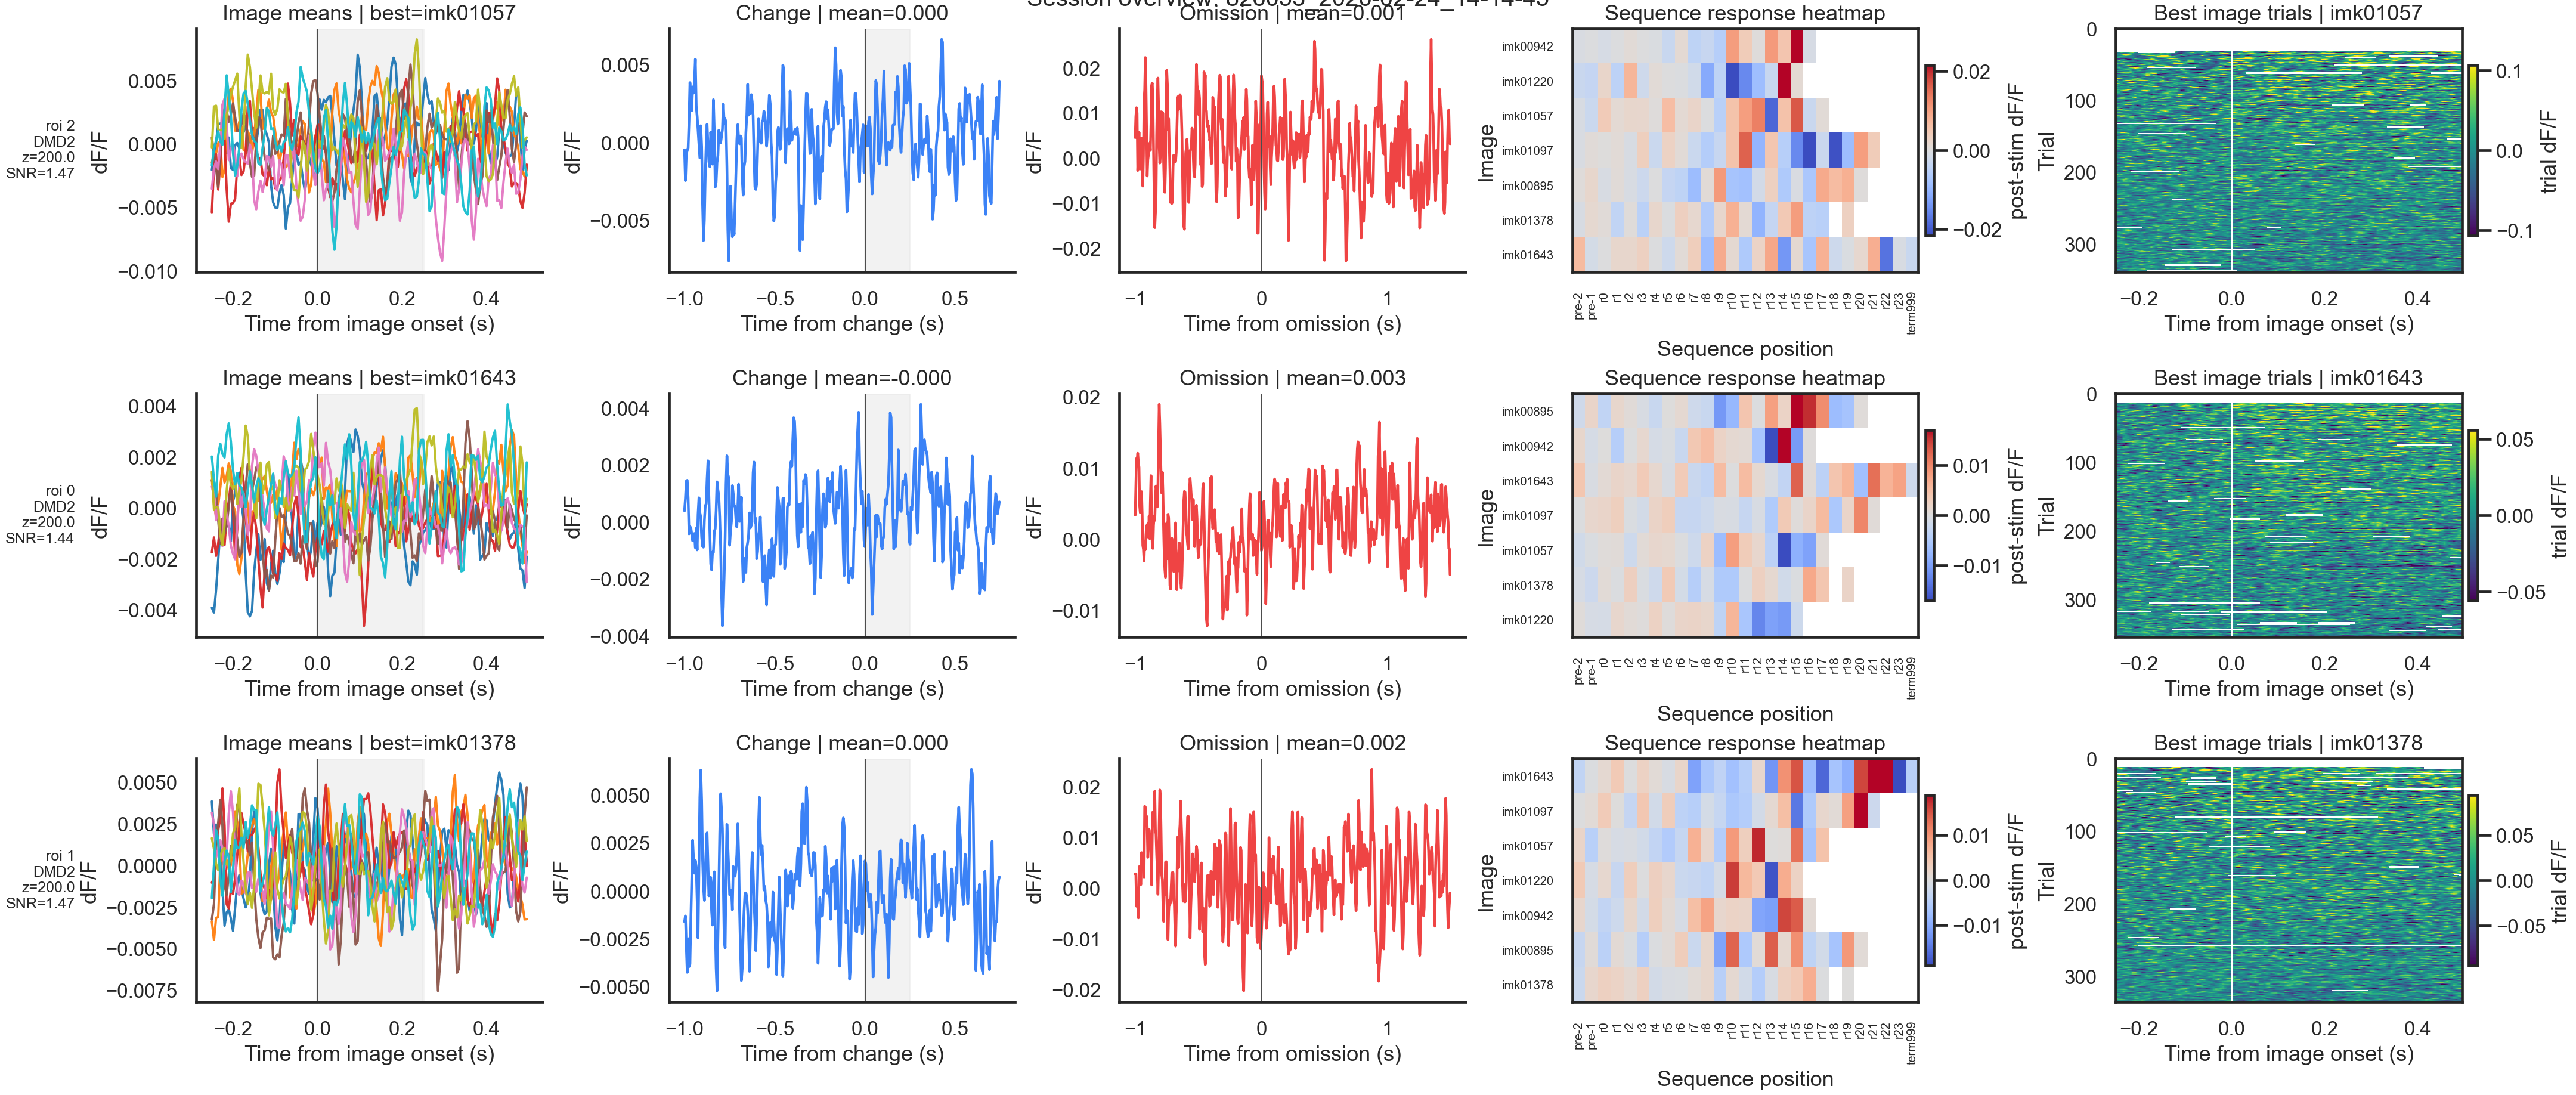

C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_39424\3469312672.py:67: RuntimeWarning: Mean of empty slice
  baseline = np.nanmean(trace[pre_mask]) if np.any(pre_mask) else 0.0
C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_39424\3450869773.py:145: RuntimeWarning: Mean of empty slice
  baselines = np.nanmean(arr[:, pre_mask], axis=1, keepdims=True)
C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_39424\3450869773.py:148: RuntimeWarning: All-NaN slice encountered
  order = np.argsort(np.nanmax(arr, axis=1))[::-1]
C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_39424\3469312672.py:67: RuntimeWarning: Mean of empty slice
  baseline = np.nanmean(trace[pre_mask]) if np.any(pre_mask) else 0.0
C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_39424\3450869773.py:145: RuntimeWarning: Mean of empty slice
  baselines = np.nanmean(arr[:, pre_mask], axis=1, keepdims=True)
C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_39424\3450869773.py:148: RuntimeWarning: All-NaN s

In [50]:
# --- choose a session to review ---

SELECT_SESSION_ID = session_browser_df.iloc[11]["session_id"]
SELECT_FOV_ID = session_browser_df.iloc[1]["fov_id"]   # e.g. "DMD1" or "DMD2"

print("Selected session:", SELECT_SESSION_ID)
print("Selected FOV:", SELECT_FOV_ID)

plot_session_overview(
    session_id=SELECT_SESSION_ID,
    fov_id=SELECT_FOV_ID,
    sort_by="best_image_post_mean",
    legend=False,
)


,session_id,session_type,fov_id,z,roi_id,robust_snr,best_image_name,best_image_post_mean,change_post_mean,omission_post_mean,sequence_peak_post_mean
19,826033_2026-02-21_09-23-34,familiar,DMD2,200.0,0,1.442753,imk01057,0.00215,-0.000119,0.002661,0.040810
20,826033_2026-02-21_09-23-34,familiar,DMD2,200.0,1,1.428526,imk01097,0.00213,0.000996,0.003370,0.043079
21,826033_2026-02-21_09-23-34,familiar,DMD2,200.0,2,1.449641,imk00459,0.00067,0.002043,0.001049,0.026712
22,826033_2026-02-21_09-23-34,familiar,DMD2,200.0,3,1.456609,imk01057,-0.00021,-0.000093,0.002626,0.022003


<IPython.core.display.Javascript object>


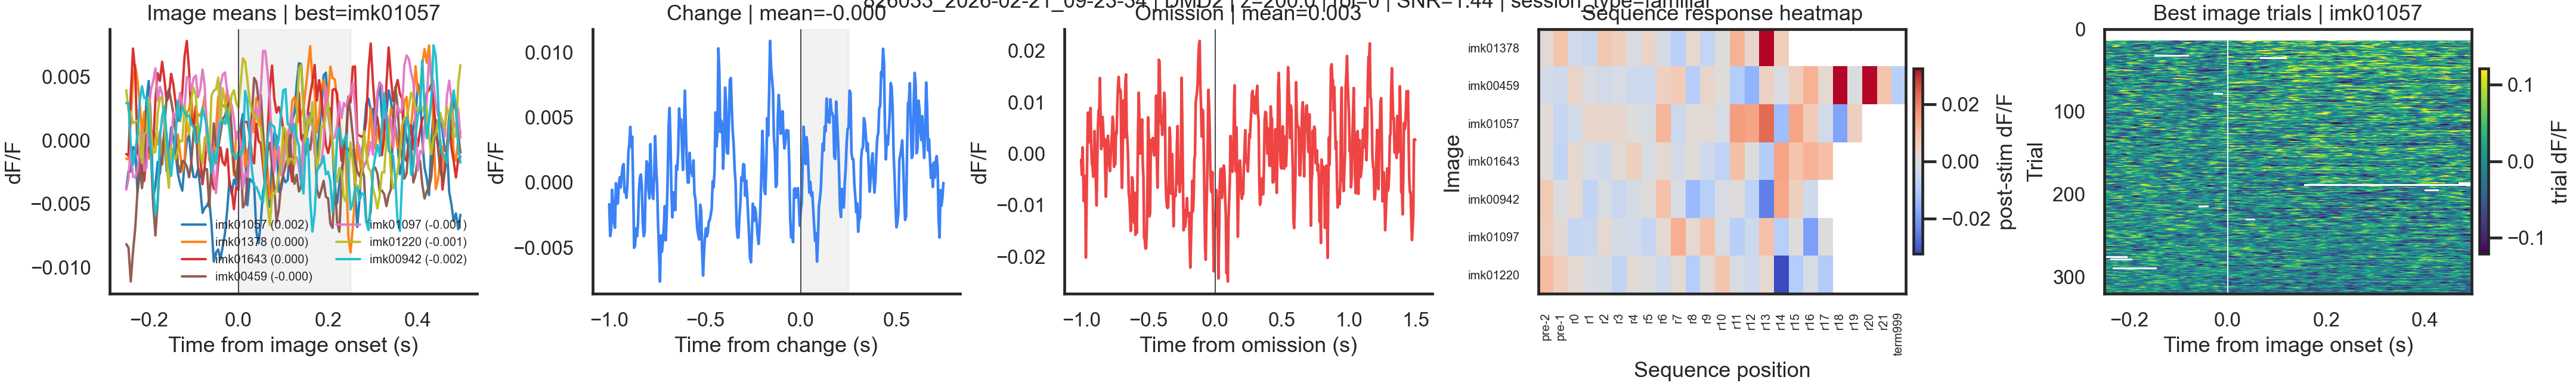

C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_39424\3450869773.py:145: RuntimeWarning: Mean of empty slice
  baselines = np.nanmean(arr[:, pre_mask], axis=1, keepdims=True)
C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_39424\3450869773.py:148: RuntimeWarning: All-NaN slice encountered
  order = np.argsort(np.nanmax(arr, axis=1))[::-1]


<IPython.core.display.Javascript object>


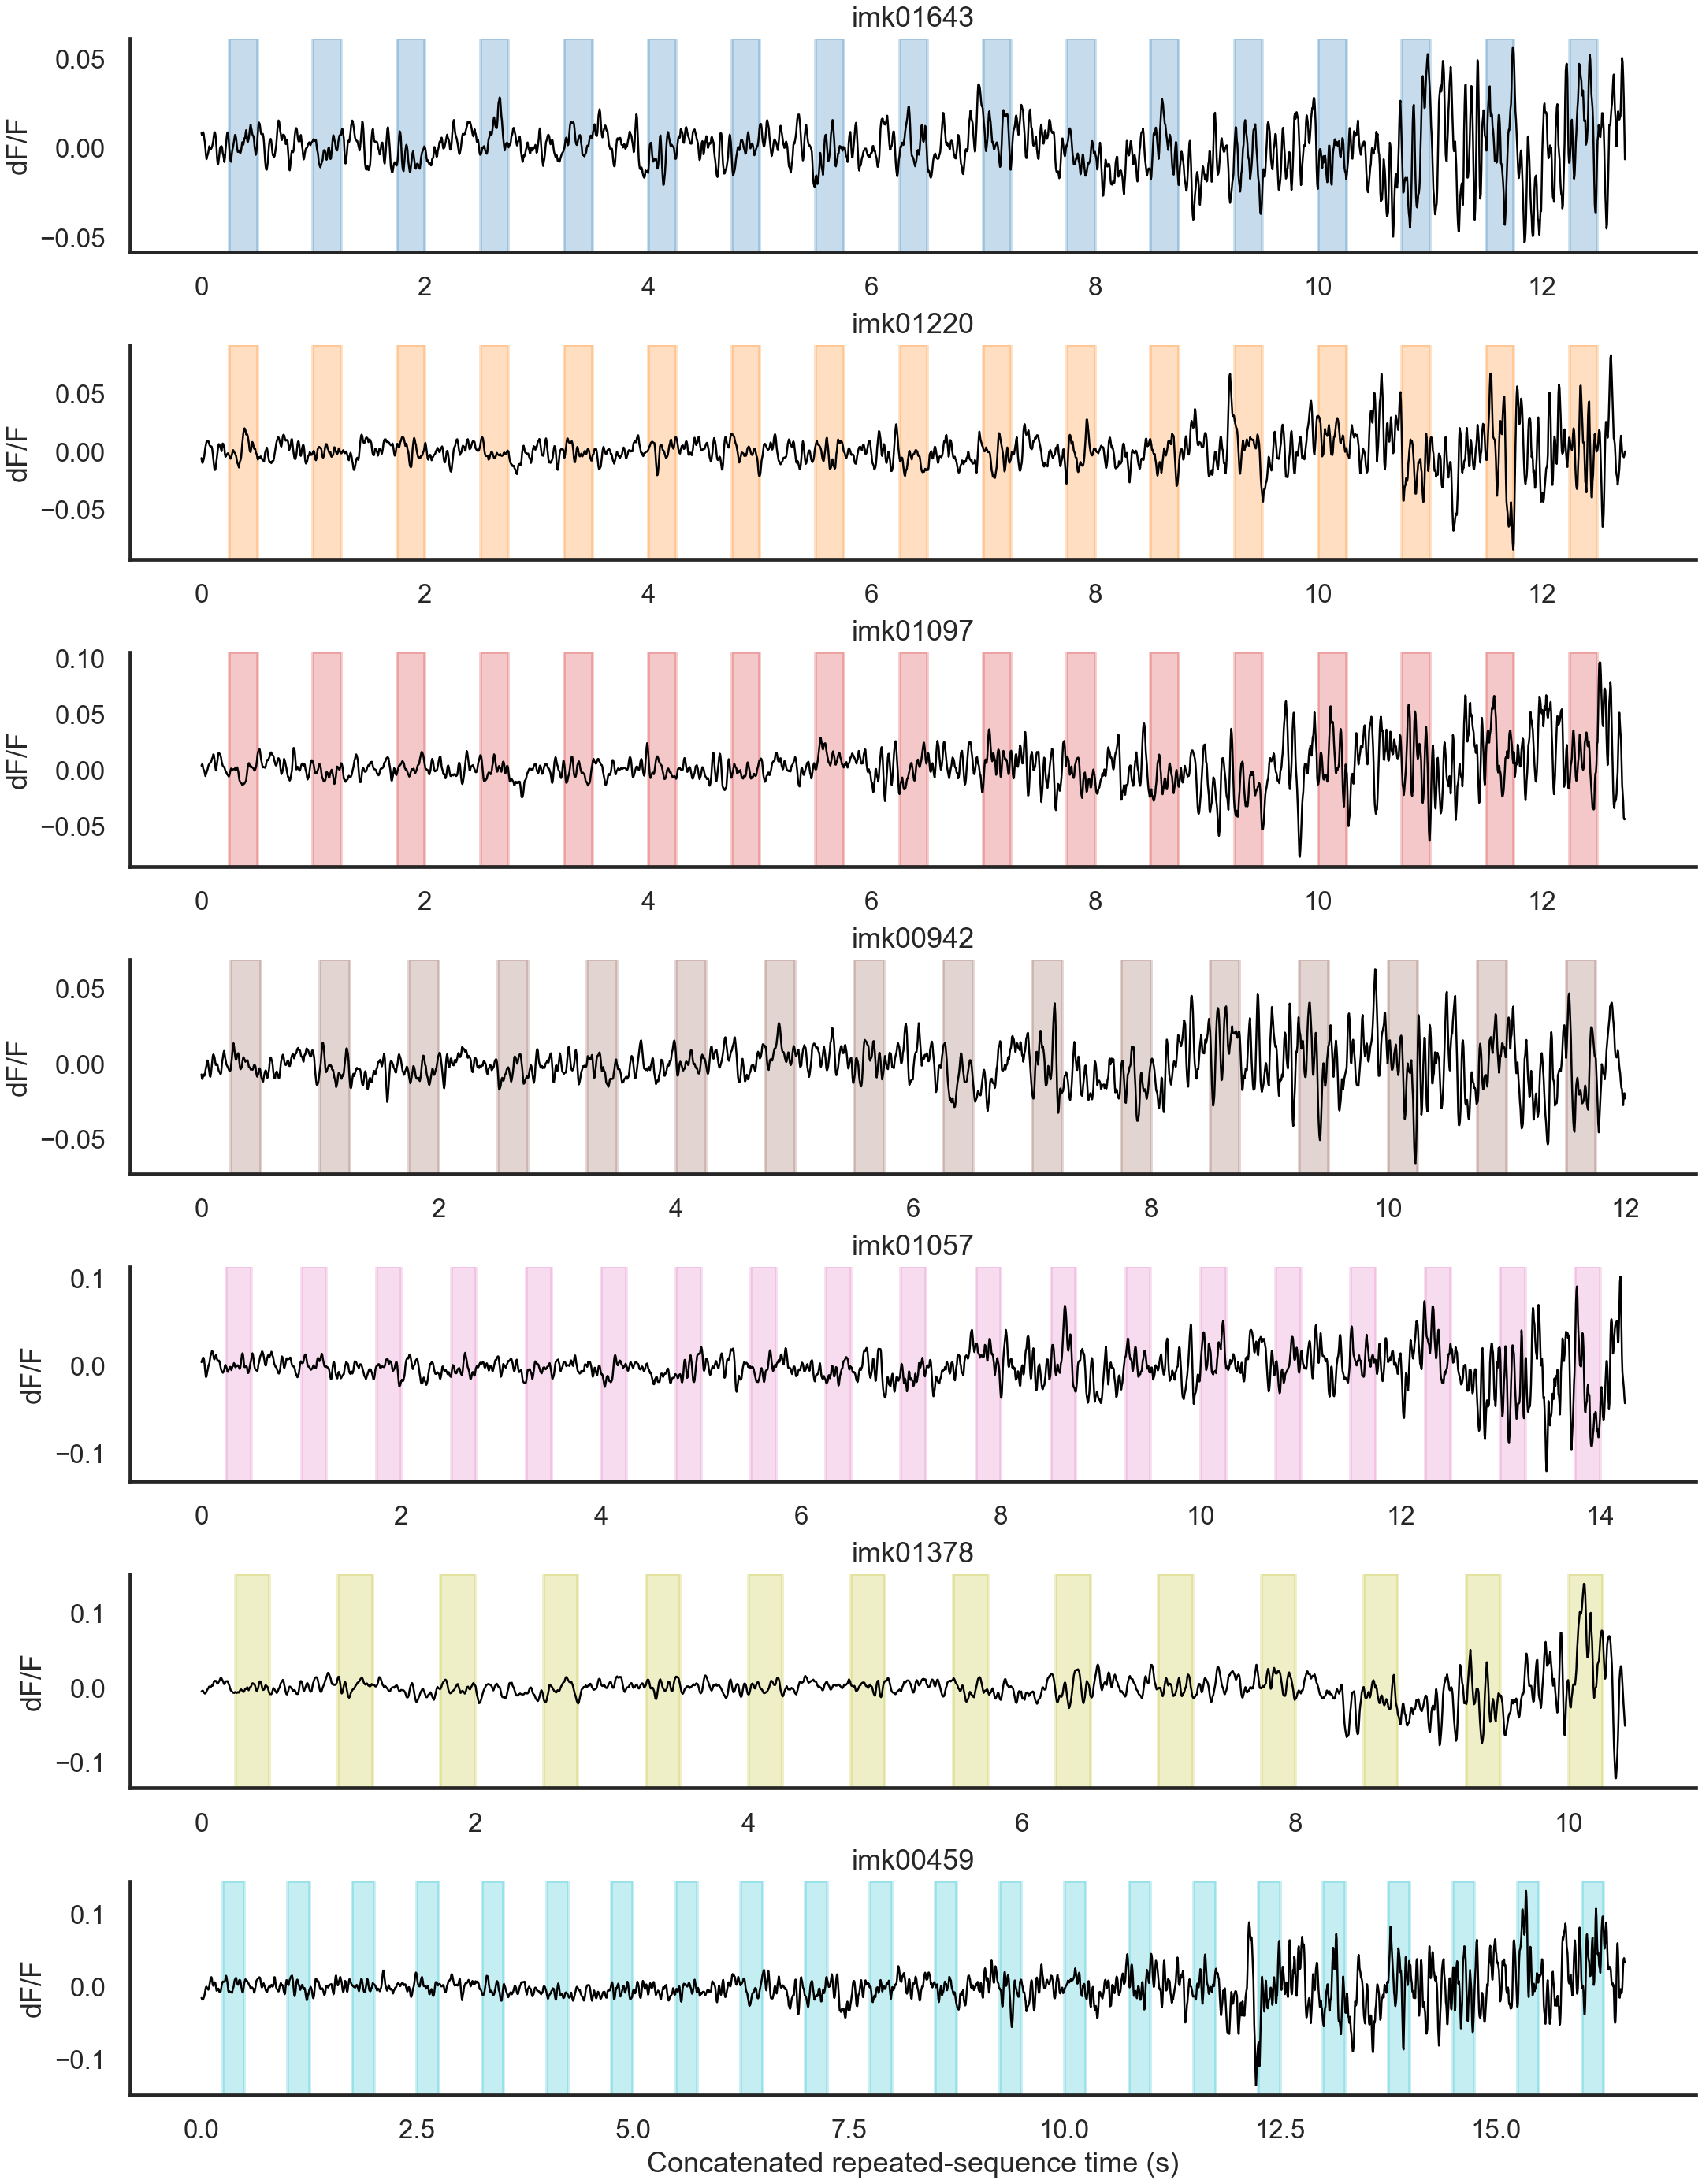

In [46]:
# --- detailed look at one ROI ---

sub = response_summary_df[
    (response_summary_df["session_id"] == SELECT_SESSION_ID) &
    (response_summary_df["fov_id"] == SELECT_FOV_ID)
].sort_values(["best_image_post_mean", "change_post_mean", "omission_post_mean"], ascending=False)

display(sub[[
    "session_id", "session_type", "fov_id", "z", "roi_id", "robust_snr",
    "best_image_name", "best_image_post_mean",
    "change_post_mean", "omission_post_mean",
    "sequence_peak_post_mean"
]])

SELECT_ROI_ID = int(sub.iloc[0]["roi_id"])

plot_roi_overview(
    session_id=SELECT_SESSION_ID,
    fov_id=SELECT_FOV_ID,
    roi_id=SELECT_ROI_ID,
    legend=True,
)

plot_sequence_detail(
    session_id=SELECT_SESSION_ID,
    fov_id=SELECT_FOV_ID,
    roi_id=SELECT_ROI_ID,
    rolling=5,
)


## Notes

A few choices here are intentionally simple and easy to edit:

- **Image activation** is summarized as the mean / peak / AUC of the post-stimulus response after subtracting the pre-stimulus baseline.
- **Change** and **Omission** use the same logic, but omission uses a longer default post window.
- The **sequence heatmap** converts each sequence-position trace into a single post-stimulus amplitude so you can quickly spot adapting vs facilitating motifs.
- The **best-image single-trial heatmap** is useful for judging whether a strong mean trace is driven by consistent trial structure or a few outliers.

Easy next extensions:
- add session-type color coding
- add automatic thresholding / response classes
- add depth-wise population plots for best image, change, and omission responses
- add a soma-vs-synapse comparison table once you decide which response metric you want to align across modalities
